In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from config import GOLD_DATA_DIR,OUTPUT_DIR, SILVER_DATASET

OUT_FILE = GOLD_DATA_DIR / "gold_databridge.csv"
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configurações aplicadas ✅")

Configurações aplicadas ✅


In [ ]:
df = pd.read_csv(SILVER_DATASET)

print(f"Registros : {len(df):,}")
print(f"Motores   : {df['ocr_engine'].unique()}")
print(f"Métodos   : {df['normalization_method'].unique()}")

Registros : 24,974
Motores   : <StringArray>
['AZURE_OCR', 'GOOGLE_VISION', 'TESSERACT']
Length: 3, dtype: str
Métodos   : <StringArray>
['RULES_V1', 'RULES_V2', 'ML_V1']
Length: 3, dtype: str


APPROVE (21,771 casos)
  ✅ Acerto — pagou em dia   : 18,410 (84.6%)
  ❌ Erro  — inadimpliu      : 3,361 (15.4%)

REVIEW (3,203 casos)
  ✅ Acerto — risco real     : 791 (24.7%)
  ⚠️  Falso alarme — pagou   : 2,412 (75.3%)

Taxa de erro geral (aprovações indevidas): 13.5%


C:\Users\Marce\AppData\Local\Temp\ipykernel_30100\1748649687.py:99: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Marce\AppData\Local\Temp\ipykernel_30100\1748649687.py:99: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Marce\AppData\Local\Temp\ipykernel_30100\1748649687.py:99: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Marce\AppData\Local\Temp\ipykernel_30100\1748649687.py:99: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Marce\AppData\Local\Temp\ipykernel_30100\1748649687.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig(f"{OUT_DIR}/sistema_05_acerto_erro.png", bbox_inches="tight")
C:\Users\Marce\AppData\Local\Temp\ipykernel_30100\1748649687.py:100: UserWarning: Glyph 10060 (\N{CROSS MARK}) miss

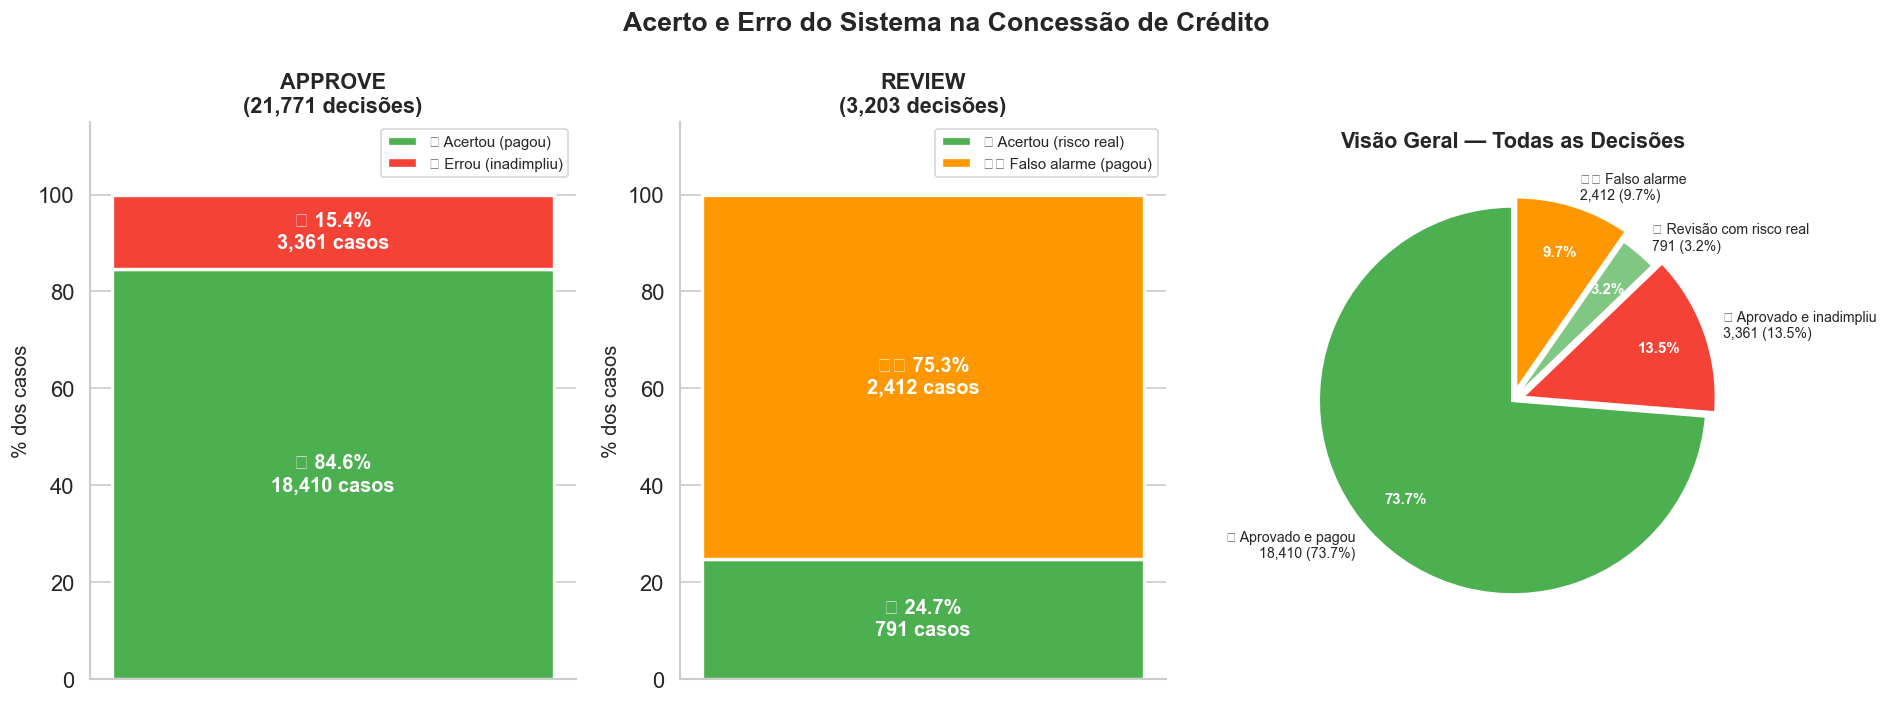

In [ ]:
# ── Matriz de acerto/erro ────────────────────────────────────────────────────
aprovados  = df[df["final_decision"] == "APPROVE"]
em_revisao = df[df["final_decision"] == "REVIEW"]

acerto_aprovado = (aprovados["default_12m"] == 0).sum()
erro_aprovado   = (aprovados["default_12m"] == 1).sum()
acerto_revisao  = (em_revisao["default_12m"] == 1).sum()
falso_alarme    = (em_revisao["default_12m"] == 0).sum()
total           = len(df)

print(f"APPROVE ({len(aprovados):,} casos)")
print(f"  ✅ Acerto — pagou em dia   : {acerto_aprovado:,} ({acerto_aprovado/len(aprovados)*100:.1f}%)")
print(f"  ❌ Erro  — inadimpliu      : {erro_aprovado:,} ({erro_aprovado/len(aprovados)*100:.1f}%)")
print()
print(f"REVIEW ({len(em_revisao):,} casos)")
print(f"  ✅ Acerto — risco real     : {acerto_revisao:,} ({acerto_revisao/len(em_revisao)*100:.1f}%)")
print(f"  ⚠️  Falso alarme — pagou   : {falso_alarme:,} ({falso_alarme/len(em_revisao)*100:.1f}%)")
print()
print(f"Taxa de erro geral (aprovações indevidas): {erro_aprovado/total*100:.1f}%")

# ── Gráfico ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Acerto e Erro do Sistema na Concessão de Crédito",
             fontsize=16, fontweight="bold")

# ── Painel 1: APPROVE ────────────────────────────────────────────────────────
labels_apr = [f"✅ Acertou\n(pagou em dia)\n{acerto_aprovado:,}",
              f"❌ Errou\n(inadimpliu)\n{erro_aprovado:,}"]
valores_apr = [acerto_aprovado/len(aprovados)*100,
               erro_aprovado/len(aprovados)*100]
cores_apr   = ["#4caf50", "#f44336"]

bars = axes[0].bar(["APPROVE"], [valores_apr[0]], color=cores_apr[0],
                   edgecolor="white", linewidth=2, width=0.5)
bars2 = axes[0].bar(["APPROVE"], [valores_apr[1]], bottom=[valores_apr[0]],
                    color=cores_apr[1], edgecolor="white", linewidth=2, width=0.5)
axes[0].text(0, valores_apr[0]/2, f"✅ {valores_apr[0]:.1f}%\n{acerto_aprovado:,} casos",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
axes[0].text(0, valores_apr[0] + valores_apr[1]/2,
             f"❌ {valores_apr[1]:.1f}%\n{erro_aprovado:,} casos",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
axes[0].set_title(f"APPROVE\n({len(aprovados):,} decisões)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("% dos casos")
axes[0].set_ylim(0, 115)
axes[0].set_xticks([])
axes[0].legend(["✅ Acertou (pagou)", "❌ Errou (inadimpliu)"],
               loc="upper right", fontsize=9)

# ── Painel 2: REVIEW ────────────────────────────────────────────────────────
valores_rev = [acerto_revisao/len(em_revisao)*100,
               falso_alarme/len(em_revisao)*100]
cores_rev   = ["#4caf50", "#ff9800"]

axes[1].bar(["REVIEW"], [valores_rev[0]], color=cores_rev[0],
            edgecolor="white", linewidth=2, width=0.5)
axes[1].bar(["REVIEW"], [valores_rev[1]], bottom=[valores_rev[0]],
            color=cores_rev[1], edgecolor="white", linewidth=2, width=0.5)
axes[1].text(0, valores_rev[0]/2,
             f"✅ {valores_rev[0]:.1f}%\n{acerto_revisao:,} casos",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
axes[1].text(0, valores_rev[0] + valores_rev[1]/2,
             f"⚠️ {valores_rev[1]:.1f}%\n{falso_alarme:,} casos",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
axes[1].set_title(f"REVIEW\n({len(em_revisao):,} decisões)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("% dos casos")
axes[1].set_ylim(0, 115)
axes[1].set_xticks([])
axes[1].legend(["✅ Acertou (risco real)", "⚠️ Falso alarme (pagou)"],
               loc="upper right", fontsize=9)

# ── Painel 3: Resumo geral ───────────────────────────────────────────────────
categorias = [
    f"✅ Aprovado e pagou\n{acerto_aprovado:,} ({acerto_aprovado/total*100:.1f}%)",
    f"❌ Aprovado e inadimpliu\n{erro_aprovado:,} ({erro_aprovado/total*100:.1f}%)",
    f"✅ Revisão com risco real\n{acerto_revisao:,} ({acerto_revisao/total*100:.1f}%)",
    f"⚠️ Falso alarme\n{falso_alarme:,} ({falso_alarme/total*100:.1f}%)",
]
valores_pizza = [acerto_aprovado, erro_aprovado, acerto_revisao, falso_alarme]
cores_pizza   = ["#4caf50", "#f44336", "#81c784", "#ff9800"]
explode       = [0, 0.05, 0, 0.05]

wedges, texts, autotexts = axes[2].pie(
    valores_pizza,
    labels=categorias,
    colors=cores_pizza,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 8.5}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
    at.set_color("white")
axes[2].set_title("Visão Geral — Todas as Decisões", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sistema_05_acerto_erro.png", bbox_inches="tight")
plt.show()


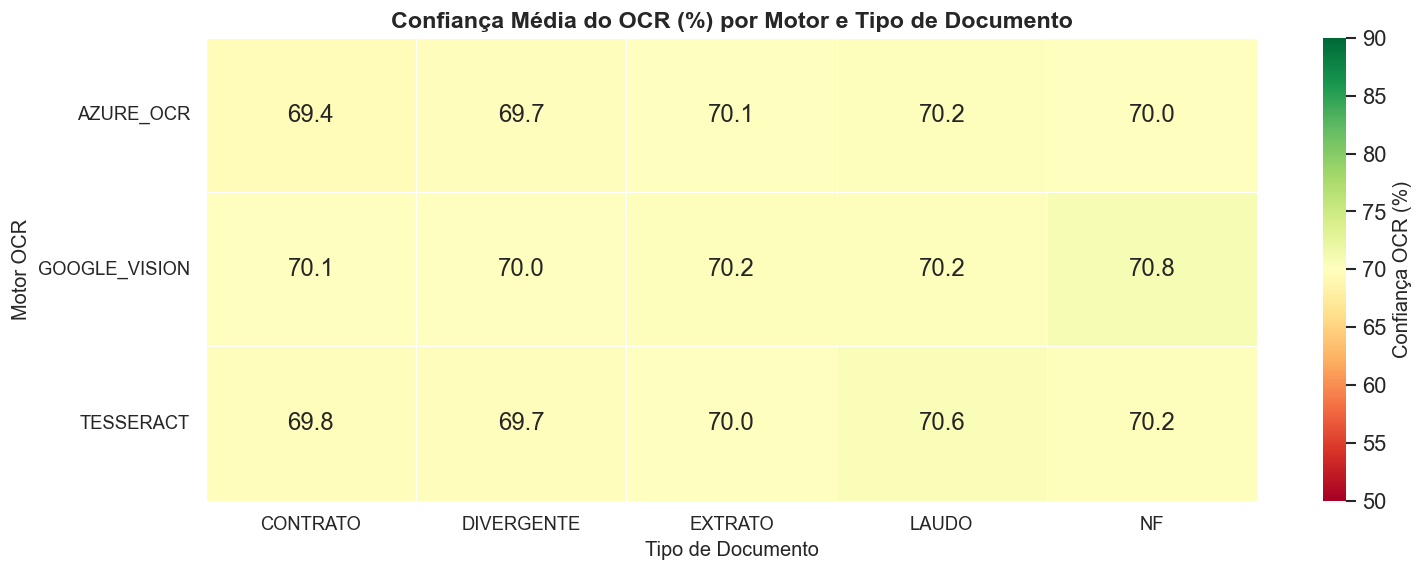

In [ ]:
pivot_conf = (
    df.groupby(["ocr_engine", "doc_type"], observed=True)["ocr_confidence"]
    .mean()
    .unstack()
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    pivot_conf,
    annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=50, vmax=90,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Confiança OCR (%)"},
    ax=ax
)
ax.set_title("Confiança Média do OCR (%) por Motor e Tipo de Documento")
ax.set_xlabel("Tipo de Documento")
ax.set_ylabel("Motor OCR")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sistema_01_confianca_ocr.png", bbox_inches="tight")
plt.show()

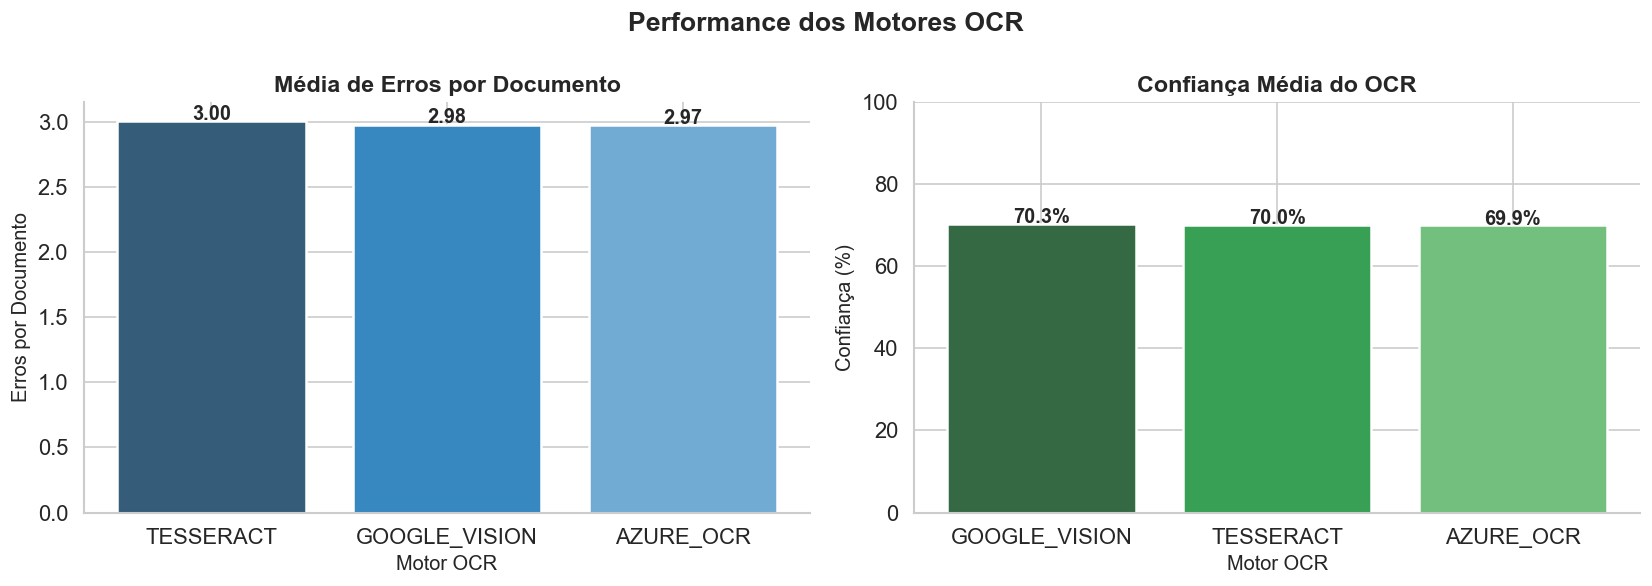

In [ ]:
erros_motor = (
    df.groupby("ocr_engine", observed=True)
    .agg(
        erros_medio    = ("ocr_error_count", "mean"),
        erros_total    = ("ocr_error_count", "sum"),
        confianca_media= ("ocr_confidence", "mean"),
        total_docs     = ("ocr_confidence", "count"),
    )
    .round(3)
    .reset_index()
    .sort_values("erros_medio", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance dos Motores OCR", fontsize=16, fontweight="bold")

cores = sns.color_palette("Blues_d", len(erros_motor))

# Erros médios
bars = axes[0].bar(erros_motor["ocr_engine"], erros_motor["erros_medio"],
                   color=cores[::-1], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, erros_motor["erros_medio"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Média de Erros por Documento")
axes[0].set_ylabel("Erros por Documento")
axes[0].set_xlabel("Motor OCR")

# Confiança média
cores2 = sns.color_palette("Greens_d", len(erros_motor))
ordem_conf = erros_motor.sort_values("confianca_media", ascending=False)
bars2 = axes[1].bar(ordem_conf["ocr_engine"], ordem_conf["confianca_media"] * 100,
                    color=cores2[::-1], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars2, ordem_conf["confianca_media"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Confiança Média do OCR")
axes[1].set_ylabel("Confiança (%)")
axes[1].set_xlabel("Motor OCR")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sistema_02_erros_motor.png", bbox_inches="tight")
plt.show()

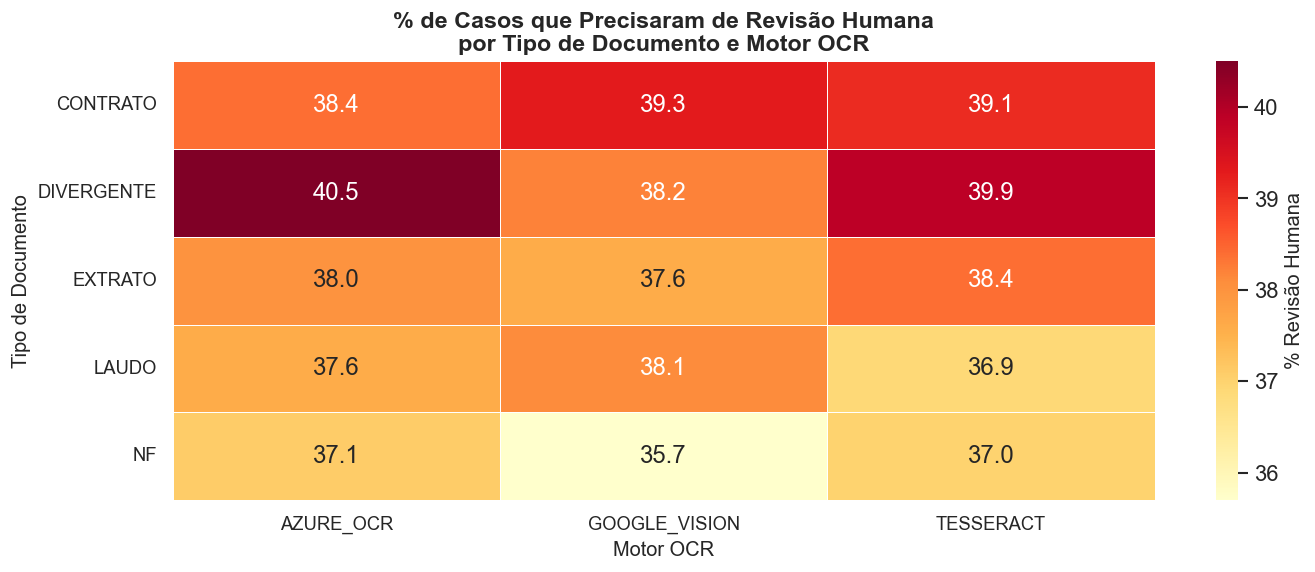

In [ ]:
revisao = (
    df.groupby(["doc_type", "ocr_engine"], observed=True)["requires_human_review"]
    .mean()
    .unstack()
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    revisao,
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "% Revisão Humana"},
    ax=ax
)
ax.set_title("% de Casos que Precisaram de Revisão Humana\npor Tipo de Documento e Motor OCR")
ax.set_xlabel("Motor OCR")
ax.set_ylabel("Tipo de Documento")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sistema_04_revisao_humana.png", bbox_inches="tight")
plt.show()